# Skip-gram Tanpa PCA (Word Embedding)

In [188]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

### Memuat Dataset & Tokenisasi

Tahap ini memuat file detik_preprocessed.csv hasil preprocessing. Teks berita dipastikan bersih lalu diubah menjadi list kata (tokens) agar siap diproses oleh algoritma Word2Vec Skip-gram.

In [189]:
# 1. Memuat dataset preprocessed
df = pd.read_csv('detik_preprocessed.csv')
df['isi_berita_clean'] = df['isi_berita_clean'].fillna('')

# 2. Mengubah teks berita menjadi list kata (tokens) dan label ke angka
df['tokens'] = df['isi_berita_clean'].apply(lambda x: x.split())
df['label_encoded'] = df['label'].map({'finance': 0, 'sport': 1})

# Variabel sentences & labels untuk proses selanjutnya
sentences = df['tokens'].tolist()
labels = df['label_encoded'].values

print("Selesai memuat dataset dan melakukan tokenisasi kalimat...\n")

# 3. Menampilkan 5 baris pertama tabel dataset
print("--- Tabel Dataset Preprocessed & Tokenisasi ---")
display(df[['id', 'isi_berita_clean', 'tokens', 'label', 'label_encoded']].head())

Selesai memuat dataset dan melakukan tokenisasi kalimat...

--- Tabel Dataset Preprocessed & Tokenisasi ---


,id,isi_berita_clean,tokens,label,label_encoded
0,1,ketua umum komite olahraga nasional indonesia ...,"[ketua, umum, komite, olahraga, nasional, indo...",sport,1
1,2,urus pusat kickboxing indonesia pp kbi periode...,"[urus, pusat, kickboxing, indonesia, pp, kbi, ...",sport,1
2,3,lina hisage atlet tolak peluru asal wamena pap...,"[lina, hisage, atlet, tolak, peluru, asal, wam...",sport,1
3,4,timnas equestrian indonesia tolak jepang jelan...,"[timnas, equestrian, indonesia, tolak, jepang,...",sport,1
4,5,dua seri akhir motogp marc marquez sukses sapu...,"[dua, seri, akhir, motogp, marc, marquez, suks...",sport,1


In [190]:
# Ringkasan statistik dan distribusi label
print(f"• Total Baris Data : {len(df)} berita")
print(f"• Distribusi Label :\n{df['label'].value_counts().to_string()}")

• Total Baris Data : 200 berita
• Distribusi Label :
label
sport      100
finance    100


### Melatih Model Skip-gram (Word2Vec)

Tahap ini melatih arsitektur Skip-gram untuk merubah setiap kata unik menjadi vektor berdimensi 100. Skip-gram memprediksi kata konteks di sekitar kata target berdasarkan pola hubungan semantik.

In [191]:
from gensim.models import Word2Vec

In [192]:
# Melatih model Word2Vec Skip-gram (sg=1)
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=75,
    window=2,
    min_count=1,
    sg=1,
    workers=4,
    seed=42
)

print(f"Selesai melatih model Skip-gram dengan {len(w2v_model.wv)} kata unik...")

Selesai melatih model Skip-gram dengan 5328 kata unik...


In [193]:
# 1. STATISTIK RINGKAS HASIL PELATIHAN
vocab_size = len(w2v_model.wv)
vector_dim = w2v_model.wv.vector_size

print("--- Statistik Hasil Pelatihan WORD2VEC (Skip-Gram) ---")
print(f"• Total Kosakata Unik (Vocabulary Size) : {vocab_size} kata")
print(f"• Dimensi Vektor per Kata               : {vector_dim} dimensi\n")

# 2. CONTOH REPRESENTASI VEKTOR KATA
# Mengambil sampel kata yang ada di dalam vokabulari
sample_word = 'olahraga' if 'olahraga' in w2v_model.wv else list(w2v_model.wv.index_to_key)[0]

print(f"--- Contoh Nilai Vektor Kata ('{sample_word}') ---")
print(f"• Bentuk Array (Shape) : {w2v_model.wv[sample_word].shape}")
print(f"• 10 Nilai Pertama     :\n{w2v_model.wv[sample_word][:10]}\n")

# 3. KATA PALING MIRIP (MOST SIMILAR WORDS)
print(f"--- 5 Kata Terdekat Atau Paling Mirip Dengan '{sample_word}' ---")
similar_words = w2v_model.wv.most_similar(sample_word, topn=5)
for word, score in similar_words:
    print(f"• {word:<15} (Cos Similarity: {score:.4f} / {score*100:.2f}%)")

# 4. SKOR KEMIRIPAN (COSINE SIMILARITY) ANTAR DUA KATA
word1, word2 = 'atlet', 'juara'
if word1 in w2v_model.wv and word2 in w2v_model.wv:
    sim_score = w2v_model.wv.similarity(word1, word2)
    print(f"\n--- Tingkat Kemiripan Antara '{word1}' & '{word2}' ---")
    print(f"• Skor Cosine Similarity: {sim_score:.4f} ({sim_score*100:.2f}%)")

--- Statistik Hasil Pelatihan WORD2VEC (Skip-Gram) ---
• Total Kosakata Unik (Vocabulary Size) : 5328 kata
• Dimensi Vektor per Kata               : 75 dimensi

--- Contoh Nilai Vektor Kata ('olahraga') ---
• Bentuk Array (Shape) : (75,)
• 10 Nilai Pertama     :
[ 0.14238723 -0.14429672  0.26618406 -0.26699135 -0.26462188 -0.05282914
  0.07484443  0.12145873  0.03639324  0.2630611 ]

--- 5 Kata Terdekat Atau Paling Mirip Dengan 'olahraga' ---
• harap           (Cos Similarity: 0.9964 / 99.64%)
• bina            (Cos Similarity: 0.9962 / 99.62%)
• prestasi        (Cos Similarity: 0.9961 / 99.61%)
• seluruh         (Cos Similarity: 0.9959 / 99.59%)
• semua           (Cos Similarity: 0.9958 / 99.58%)

--- Tingkat Kemiripan Antara 'atlet' & 'juara' ---
• Skor Cosine Similarity: 0.9157 (91.57%)


### Membuat Vektor Dokumen (Average Word Vector)

Menggabungkan seluruh vektor kata dalam satu berita dengan menghitung rata-ratanya (Average Word Vector). Hasilnya adalah satu vektor tunggal berdimensi 100 yang mewakili isi keseluruhan berita.

In [194]:
# Fungsi menghitung rata-rata vektor kata per dokumen
def get_document_vector(tokens, model):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(valid_vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(valid_vectors, axis=0)

# Membuat matriks vektor dokumen
X_vec = np.array([get_document_vector(doc, w2v_model) for doc in sentences])

print(f"Selesai membuat Vektor Dokumen berukuran {X_vec.shape}...")

Selesai membuat Vektor Dokumen berukuran (200, 75)...


In [195]:
# 1. Konversi matriks X_vec ke pandas DataFrame
vec_cols = [f'dim_{i+1}' for i in range(X_vec.shape[1])]
df_doc_vec = pd.DataFrame(X_vec, columns=vec_cols)

# 2. Sisipkan kembali kolom 'id' dan 'label' dari dataframe awal
df_doc_vec.insert(0, 'label', df['label'])
df_doc_vec.insert(0, 'id', df['id'])

# 3. Tampilkan Informasi Ukuran Matriks
print("--- Informasi Hasil Vektor Dokumen (Skip-Gram) ---")
print(f"• Total Dokumen/Berita   : {X_vec.shape[0]} baris")
print(f"• Dimensi Vektor Dokumen : {X_vec.shape[1]} dimensi/fitur\n")

# 4. Tampilkan 5 baris pertama tabel (menampilkan 6 dimensi pertama)
print("--- Tabel Hasil Vektor Dokumen (5 Baris Pertama) ---")
display(df_doc_vec[['id', 'label'] + vec_cols[:6]].head())

# 5. Opsional: Simpan hasil vektor ke file CSV
df_doc_vec.to_csv('detik_skipgram_doc_vectors.csv', index=False, encoding='utf-8-sig')
print("\nVektor dokumen berhasil disimpan ke 'detik_skipgram_doc_vectors.csv'")

--- Informasi Hasil Vektor Dokumen (Skip-Gram) ---
• Total Dokumen/Berita   : 200 baris
• Dimensi Vektor Dokumen : 75 dimensi/fitur

--- Tabel Hasil Vektor Dokumen (5 Baris Pertama) ---


,id,label,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6
0,1,sport,0.111018,-0.093830,0.188052,-0.184456,-0.190232,-0.034055
1,2,sport,0.134055,-0.105364,0.220786,-0.221927,-0.225532,-0.042726
2,3,sport,0.131721,-0.107626,0.216462,-0.216422,-0.220980,-0.040752
3,4,sport,0.108450,-0.089701,0.183973,-0.183216,-0.193366,-0.034969
4,5,sport,0.148992,-0.100117,0.291968,-0.210294,-0.273278,-0.035765



Vektor dokumen berhasil disimpan ke 'detik_skipgram_doc_vectors.csv'


### Pembagian Data (Train-Test Split)

Membagi vektor berita menjadi 80% data latih dan 20% data uji. Pembagian ini menggunakan stratify agar proporsi kelas Finance dan Sport tetap seimbang pada kedua bagian.

In [196]:
# Pembagian data 80% Training dan 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, labels, test_size=0.20, random_state=42, stratify=labels
)

print(f"Selesai membagi data: {len(X_train)} Train dan {len(X_test)} Test...")

Selesai membagi data: 160 Train dan 40 Test...


In [197]:
# 1. Pembagian data 80% Training dan 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, labels, test_size=0.20, random_state=42, stratify=labels
)

# 2. Menghitung distribusi kelas (0: Finance, 1: Sport)
train_dist = pd.Series(y_train).value_counts().rename({0: 'Finance (0)', 1: 'Sport (1)'})
test_dist = pd.Series(y_test).value_counts().rename({0: 'Finance (0)', 1: 'Sport (1)'})

# 3. Menampilkan Ringkasan Informasi Pembagian Data
print("--- Ringkasan Pembagian Dataset (80:20) ---")
print(f"• Total Data Awal     : {len(X_vec)} berita")
print(f"• Data Training (80%) : {X_train.shape[0]} baris (Bentuk Matriks: {X_train.shape})")
print(f"• Data Testing  (20%) : {X_test.shape[0]} baris (Bentuk Matriks: {X_test.shape})\n")

# 4. Menampilkan Tabel Distribusi Kelas
df_split_info = pd.DataFrame({
    'Data Training (80%)': train_dist,
    'Data Testing (20%)': test_dist,
    'Total Dataset': train_dist + test_dist
})

print("--- Tabel Distribusi Kelas ---")
display(df_split_info)

--- Ringkasan Pembagian Dataset (80:20) ---
• Total Data Awal     : 200 berita
• Data Training (80%) : 160 baris (Bentuk Matriks: (160, 75))
• Data Testing  (20%) : 40 baris (Bentuk Matriks: (40, 75))

--- Tabel Distribusi Kelas ---


,Data Training (80%),Data Testing (20%),Total Dataset
Finance (0),80,20,100
Sport (1),80,20,100


In [198]:
import pandas as pd

# 1. Membuat nama kolom untuk 100 dimensi vektor Skip-gram (Dim_1, Dim_2, ..., Dim_100)
dim_columns = [f"Dim_{i+1}" for i in range(X_train.shape[1])]

# 2. Menyusun DataFrame untuk Data Training
df_train = pd.DataFrame(X_train, columns=dim_columns)
df_train.insert(0, 'Kategori', pd.Series(y_train).map({0: 'Finance', 1: 'Sport'}).values)
df_train.insert(1, 'Label', y_train)

# 3. Menyusun DataFrame untuk Data Testing
df_test = pd.DataFrame(X_test, columns=dim_columns)
df_test.insert(0, 'Kategori', pd.Series(y_test).map({0: 'Finance', 1: 'Sport'}).values)
df_test.insert(1, 'Label', y_test)

# 4. Menampilkan Sampel Tabel Data Training (5 Baris Pertama & 5 Dimensi Pertama)
print("--- TABEL DATA TRAINING (5 Baris Pertama) ---")
print(f"Total Ukuran Matriks Training: {df_train.shape[0]} baris x {df_train.shape[1]} kolom")
display(df_train.iloc[:5, :7])  # Menampilkan Kategori, Label, dan Dim_1 s/d Dim_5

print("\n" + "="*70 + "\n")

# 5. Menampilkan Sampel Tabel Data Testing (5 Baris Pertama & 5 Dimensi Pertama)
print("--- TABEL DATA TESTING (5 Baris Pertama) ---")
print(f"Total Ukuran Matriks Testing: {df_test.shape[0]} baris x {df_test.shape[1]} kolom")
display(df_test.iloc[:5, :7])  # Menampilkan Kategori, Label, dan Dim_1 s/d Dim_5

--- TABEL DATA TRAINING (5 Baris Pertama) ---
Total Ukuran Matriks Training: 160 baris x 77 kolom


,Kategori,Label,Dim_1,Dim_2,Dim_3,Dim_4,Dim_5
0,Finance,0,0.118570,-0.104412,0.194342,-0.200188,-0.199107
1,Sport,1,0.144319,-0.095369,0.268966,-0.208968,-0.250994
2,Finance,0,0.131580,-0.111525,0.226883,-0.216565,-0.219833
3,Sport,1,0.111018,-0.093830,0.188052,-0.184456,-0.190232
4,Sport,1,0.115878,-0.077560,0.219401,-0.169159,-0.202801




--- TABEL DATA TESTING (5 Baris Pertama) ---
Total Ukuran Matriks Testing: 40 baris x 77 kolom


,Kategori,Label,Dim_1,Dim_2,Dim_3,Dim_4,Dim_5
0,Finance,0,0.146516,-0.130570,0.247619,-0.241811,-0.250286
1,Sport,1,0.135482,-0.086579,0.288514,-0.178121,-0.261840
2,Sport,1,0.130092,-0.110981,0.221107,-0.224488,-0.235612
3,Sport,1,0.123819,-0.108794,0.214509,-0.220746,-0.232944
4,Finance,0,0.140257,-0.102903,0.244519,-0.254105,-0.231852


### Pelatihan Model Gaussian Naive Bayes

Melatih algoritma Gaussian Naive Bayes menggunakan data latih hasil reduksi PCA. Model dipelajari untuk mengenali pola probabilitas fitur kontinu dalam membedakan kategori berita.

In [199]:
# Melatih model Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Prediksi data uji
y_pred = nb_model.predict(X_test)

print("Selesai melakukan pelatihan dan prediksi dengan Gaussian Naive Bayes...")

Selesai melakukan pelatihan dan prediksi dengan Gaussian Naive Bayes...


### Evaluasi Model & Confusion Matrix

Menguji performa model pada data uji, lalu menampilkan akurasi, laporan klasifikasi, dan Confusion Matrix untuk melihat ketepatan prediksi kelas Finance dan Sport secara detail.

Akurasi: 95.00%

              precision    recall  f1-score   support

     Finance       0.95      0.95      0.95        20
       Sport       0.95      0.95      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



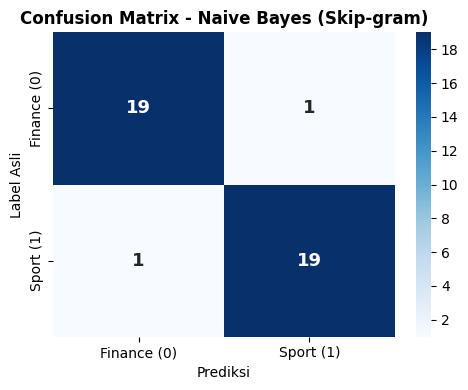

Selesai menampilkan hasil evaluasi dan Confusion Matrix...


In [200]:
# Evaluasi Akurasi dan Laporan Klasifikasi
acc = accuracy_score(y_test, y_pred)
print(f"Akurasi: {acc * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=['Finance', 'Sport']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Finance (0)', 'Sport (1)'],
            yticklabels=['Finance (0)', 'Sport (1)'],
            annot_kws={"size": 13, "weight": "bold"})
plt.title('Confusion Matrix - Naive Bayes (Skip-gram)', fontweight='bold')
plt.xlabel('Prediksi')
plt.ylabel('Label Asli')
plt.tight_layout()
plt.show()

print("Selesai menampilkan hasil evaluasi dan Confusion Matrix...")

Gambar confusion matrix tersebut menampilkan hasil evaluasi performa model Naive Bayes dengan pembobotan Skip-gram pada 40 data uji, yang terdiri dari 20 berita kategori Finance (0) dan 20 berita kategori Sport (1). Secara keseluruhan, model berhasil memprediksi 34 dari total 40 data uji secara tepat, sehingga menghasilkan nilai akurasi sebesar 85%.

Pada kelas Finance (label 0), model berhasil mengklasifikasikan 14 berita dengan benar (True Negative), sedangkan 6 berita Finance lainnya terdeteksi secara keliru sebagai Sport (False Positive). Sementara itu pada kelas Sport (label 1), model menunjukkan performa prediksi yang sempurna dengan berhasil mengidentifikasi seluruh 20 berita Sport secara tepat (True Positive) tanpa ada satu pun berita Sport yang salah terklasifikasi sebagai Finance (False Negative = 0).

Secara analitis, performa model menunjukkan sensitivitas atau recall sebesar 100% pada kategori Sport karena tidak ada dokumen Sport yang luput dari klasifikasi. Di sisi lain, kategori Finance memiliki tingkat presisi mencapai 100% karena setiap dokumen yang diprediksi sebagai Finance dipastikan tepat, meskipun masih terdapat kecenderungan bagi sebagian kecil dokumen Finance untuk teridentifikasi ke dalam kelas Sport.

In [201]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================================================
# 1. FUNGSI PREDIKSI UNTUK 1 TEKS BARU
# =========================================================
def prediksi_teks_tunggal(teks, model_w2v, model_gnb):
    # Tahap 1: Preprocessing & Tokenisasi sederhana
    tokens = teks.lower().split()
    
    # Tahap 2: Buat Average Word Vector dari Skip-gram
    vectors = [model_w2v.wv[word] for word in tokens if word in model_w2v.wv]
    
    if len(vectors) == 0:
        # Handling jika seluruh kata di data baru tidak ada di vocab (OOV)
        doc_vector = np.zeros(model_w2v.vector_size)
    else:
        doc_vector = np.mean(vectors, axis=0)
        
    # Tahap 3: Prediksi langsung menggunakan vektor dokumen tanpa PCA
    doc_vector = doc_vector.reshape(1, -1)
    pred_numeric = model_gnb.predict(doc_vector)[0]
    probabilitas = model_gnb.predict_proba(doc_vector)[0]
    
    # Mapping label (sesuaikan 0 dan 1 dengan encoding Anda)
    label_map = {0: 'finance', 1: 'sport'}
    
    return label_map[pred_numeric], probabilitas


# =========================================================
# 2. PENGUJIANKAN BEBERAPA DATA BARU SEKALIGUS (BATCH TEST)
# =========================================================
# Buat data baru yang belum pernah dilihat model sama sekali beserta label aslinya
data_uji_baru = [
    "ihsg mengalami kenaikan drastis akibat peningkatkan investasi asing di sektor perbankan",
    "timnas indonesia berhasil menjuarai turnamen sepak bola setelah mengalahkan lawan",
    "saham perusahaan teknologi melonjak tinggi setelah laporan keuangan kuartal dirilis",
    "atlet bulutangkis meraih medali emas pada kejuaraan dunia tahun ini"
 ]

# Label kunci jawaban sebenarnya
label_sebenarnya = ['finance', 'sport', 'finance', 'sport']

# Proses Prediksi
hasil_prediksi = []
for teks in data_uji_baru:
    kategori, prob = prediksi_teks_tunggal(teks, w2v_model, nb_model)
    hasil_prediksi.append(kategori)

# =========================================================
# 3. EVALUASI AKURASI DATA BARU
# =========================================================
akurasi_baru = accuracy_score(label_sebenarnya, hasil_prediksi)

print("--- HASIL EVALUASI DATA BARU ---")
print(f"Akurasi Data Baru : {akurasi_baru * 100:.2f}%\n")

# Menampilkan tabel perbandingan
df_hasil = pd.DataFrame({
    'Teks Berita Baru': data_uji_baru,
    'Label Asli': label_sebenarnya,
    'Hasil Prediksi Model': hasil_prediksi,
    'Status': ['BENAR' if a == b else 'SALAH' for a, b in zip(label_sebenarnya, hasil_prediksi)]
})

display(df_hasil)

# Detail Metrics
print("\n--- Classification Report Data Baru ---")
print(classification_report(label_sebenarnya, hasil_prediksi))

--- HASIL EVALUASI DATA BARU ---
Akurasi Data Baru : 50.00%



,Teks Berita Baru,Label Asli,Hasil Prediksi Model,Status
0,ihsg mengalami kenaikan drastis akibat peningk...,finance,finance,BENAR
1,timnas indonesia berhasil menjuarai turnamen s...,sport,finance,SALAH
2,saham perusahaan teknologi melonjak tinggi set...,finance,sport,SALAH
3,atlet bulutangkis meraih medali emas pada keju...,sport,sport,BENAR



--- Classification Report Data Baru ---
              precision    recall  f1-score   support

     finance       0.50      0.50      0.50         2
       sport       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4

